# Ice Tea Sales Forecasting with Multivariate OLS Regression

This project analyses 52 weeks of ice tea sales to understand what drives revenue: advertising (Search, Newspaper, Social Media), pricing, temperature, and holidays. The goal is to build a regression model that can forecast revenue and support marketing budget decisions.

The regression framework follows James et al., *An Introduction to Statistical Learning with Python* (2023, Chapter 3).



## Table of Contents

**A. Data Import and Quality Checks**
- A.1 Libraries and Data Loading
- A.2 Variable Types
- A.3 Data Quality

**B. Exploratory Data Analysis (EDA)**
- B.1 Revenue Over Time
- B.2 Revenue and Temperature
- B.3 Advertising Budget and Timing
- B.4 Scatter Plots
- B.5 Correlation Analysis

**C. Multicollinearity Diagnostics (VIF)**

**D. Ordinary Least Squares Modeling (OLS)**
- D.1 Baseline vs Full Model
- D.2 Coefficient Interpretation

**E. Train/Test Forecasting**

**F. Residual Analysis**

**G. Conclusions and Recommendations**
- G.1 Media Contribution Analysis
- G.2 Summary and Recommendations

## A. Data Import and Quality Checks

### A.1 Libraries and Data Loading

In [87]:
#import libraries

import pandas as pd     #data manipulation
import numpy as np      #numerical operations
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm         #OLS regression and inference
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF   #multicollinearity diagnostic
from statsmodels.stats.stattools import durbin_watson

from sklearn.metrics import mean_squared_error as MSE
from scipy import stats

In [88]:
#mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
#load dataset
df = pd.read_csv('/content/drive/MyDrive/Maria V/2026/Sales Analyst VW - Github/Sales Forecasting with OLS Regression: Iced Tea/CSV originale/Copia di Copia di marketing.csv')

In [90]:
#check dimensions, column names, data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Week          52 non-null     int64  
 1   Revenue       52 non-null     int64  
 2   Newspaper     52 non-null     int64  
 3   Search        52 non-null     int64  
 4   Social_media  52 non-null     int64  
 5   Price_delta   52 non-null     float64
 6   Temperature   52 non-null     float64
 7   Holiday       52 non-null     int64  
dtypes: float64(2), int64(6)
memory usage: 3.4 KB


The dataset has 52 weekly observations and 7 columns. Revenue is the dependent variable, the other six are predictors.

### A.2 Variable Types

I check how many distinct values each variable takes to decide how to treat them in the model.

In [91]:
#statistical summary: Revenue is Y, the others are X
df.describe().round(2)

,Week,Revenue,Newspaper,Search,Social_media,Price_delta,Temperature,Holiday
count,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00
mean,26.50,3444.52,46.15,19.62,18.85,0.09,54.52,0.19
std,15.15,870.94,85.09,15.14,40.69,0.30,15.05,0.40
min,1.00,2323.00,0.00,0.00,0.00,-0.20,32.30,0.00
25%,13.75,2728.50,0.00,10.00,0.00,-0.20,41.58,0.00
50%,26.50,3311.00,0.00,15.00,0.00,0.00,50.30,0.00
75%,39.25,3958.25,0.00,20.00,0.00,0.50,66.62,0.00
max,52.00,5428.00,200.00,50.00,140.00,0.50,80.20,1.00


In [92]:
#Newspaper only takes 2 values, so it is binary
df['Newspaper'].value_counts()

,count
Newspaper,
0,40
200,12


In [93]:
#same for Social Media
df['Social_media'].value_counts()

,count
Social_media,
0,40
70,4
140,4
35,4


In [94]:
#Price delta takes only 3 values, so I treat it as categorical
df['Price_delta'].value_counts()

,count
Price_delta,
-0.2,20
0.5,17
0.0,15


In [95]:
#Holiday is binary by definition
df['Holiday'].value_counts()

,count
Holiday,
0,42
1,10


In [96]:
#Search takes many values, so I treat it as continuous
df['Search'].value_counts()

,count
Search,
15,12
20,11
10,9
0,8
40,7
50,5


Newspaper, Social Media, and Holiday are binary. Price Delta only takes three fixed values so I treat it as categorical. Search and Temperature vary continuously and are treated as continuous. Revenue is a continuous monetary variable.

### A.3 Data Quality

In [97]:
#check missing values
df.isnull().sum()

,0
Week,0
Revenue,0
Newspaper,0
Search,0
Social_media,0
Price_delta,0
Temperature,0
Holiday,0


In [98]:
#check duplicates
df.duplicated().sum()

np.int64(0)

No missing values, no duplicates. The dataset is clean.

## B. Exploratory Data Analysis (EDA)

### B.1 Revenue Over Time

I plot revenue across 52 weeks to get a first look at the seasonal pattern and see whether holiday weeks stand out.

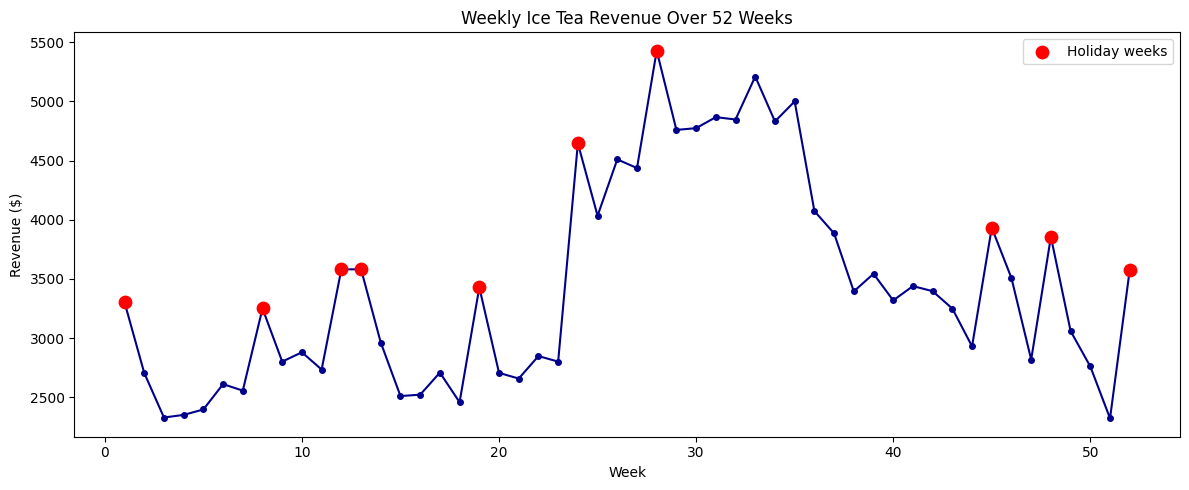

In [99]:
#revenue over time with holiday weeks highlighted
plt.figure(figsize=(12, 5))
plt.plot(df['Week'], df['Revenue'], color='darkblue', linewidth=1.5, marker='o', markersize=4)

#highlight holiday weeks to see if they behave differently
holidays = df[df['Holiday'] == 1]
plt.scatter(holidays['Week'], holidays['Revenue'], color='red', s=80, zorder=5, label='Holiday weeks')

plt.xlabel('Week')
plt.ylabel('Revenue ($)')
plt.title('Weekly Ice Tea Revenue Over 52 Weeks')
plt.legend()
plt.tight_layout()
plt.show()

Revenue is low in winter, rises through spring, peaks in summer (weeks 24-35, max 5428 in week 28) and drops again in autumn. Holiday weeks consistently spike above their neighbours throughout the whole year, not just in summer. Week 8 in winter reached 3251 while surrounding weeks stayed around 2600, which suggests Holiday has an effect independent from seasonality.

### B.2 Revenue and Temperature

Ice tea is a warm-weather product, so temperature is the most obvious seasonal driver. I overlay the two series to see how closely they move together.

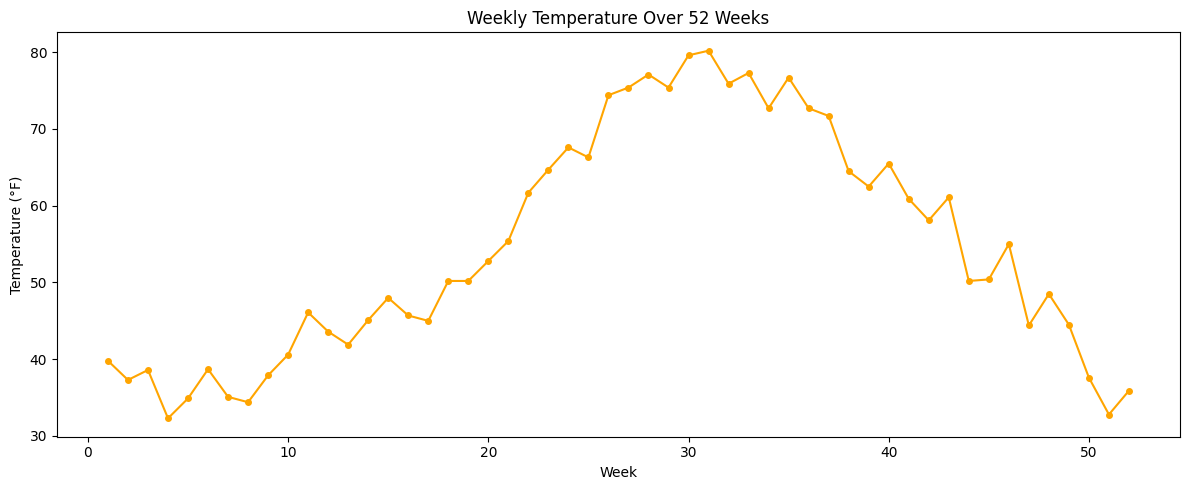

In [100]:
#temperature over time to see the seasonal shape
plt.figure(figsize=(12, 5))
plt.plot(df['Week'], df['Temperature'], color='orange', linewidth=1.5, marker='o', markersize=4)
plt.xlabel('Week')
plt.ylabel('Temperature (°F)')
plt.title('Weekly Temperature Over 52 Weeks')
plt.tight_layout()
plt.show()

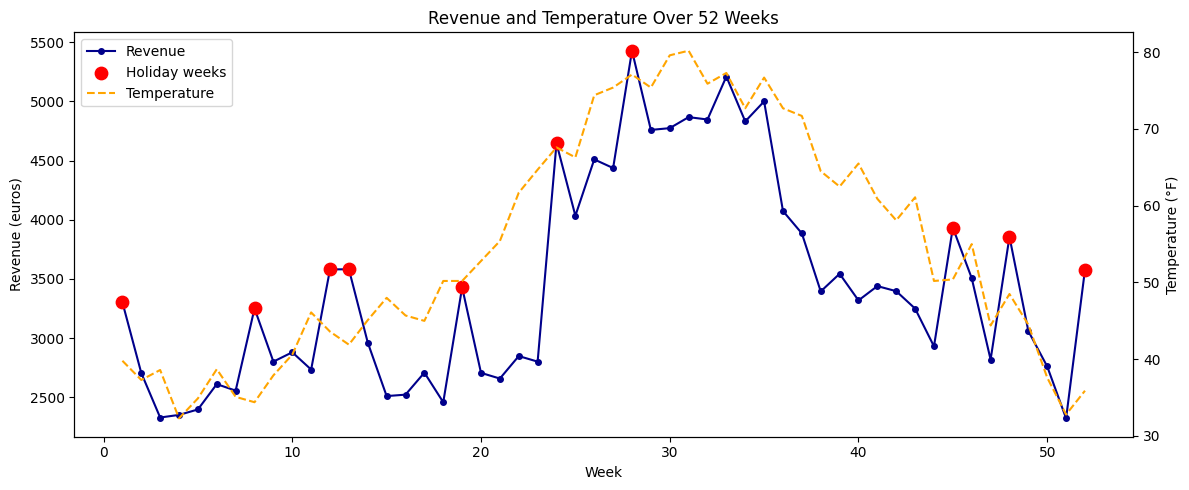

In [101]:
#overlay revenue and temperature on the same chart to compare their shapes
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df['Week'], df['Revenue'], color='darkblue', linewidth=1.5, marker='o', markersize=4, label='Revenue')
holidays = df[df['Holiday'] == 1]
ax1.scatter(holidays['Week'], holidays['Revenue'], color='red', s=80, zorder=5, label='Holiday weeks')
ax1.set_xlabel('Week')
ax1.set_ylabel('Revenue (euros)')

#second y-axis for temperature since the scales are different
ax2 = ax1.twinx()
ax2.plot(df['Week'], df['Temperature'], color='orange', linewidth=1.5, linestyle='--', label='Temperature')
ax2.set_ylabel('Temperature (°F)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Revenue and Temperature Over 52 Weeks')
plt.tight_layout()
plt.show()

The two curves are almost identical in shape. Peak revenue in week 28 coincides with peak temperature (77F), and the lowest revenue week is also one of the coldest. Week 28 is also a holiday week though, so multiple factors overlap here and visual inspection alone cannot separate them.

### B.3 Advertising Budget and Timing

I look at how the budget is split across channels and when it was actually spent during the year.

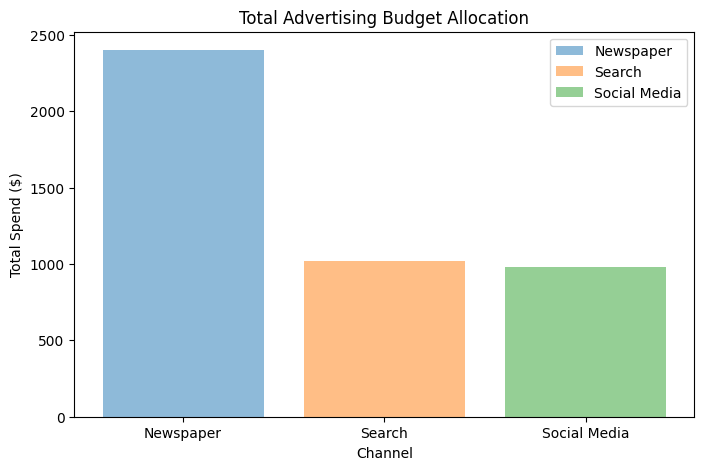

In [102]:
#total spend per channel to see budget allocation
plt.figure(figsize=(8, 5))
plt.bar('Newspaper', df['Newspaper'].sum(), label='Newspaper', alpha=0.5)
plt.bar('Search', df['Search'].sum(), label='Search', alpha=0.5)
plt.bar('Social Media', df['Social_media'].sum(), label='Social Media', alpha=0.5)
plt.xlabel('Channel')
plt.ylabel('Total Spend ($)')
plt.title('Total Advertising Budget Allocation')
plt.legend()
plt.show()

Newspaper received the largest share of total spend. Total spend alone does not tell us much about timing though, so I look at the weekly distribution.

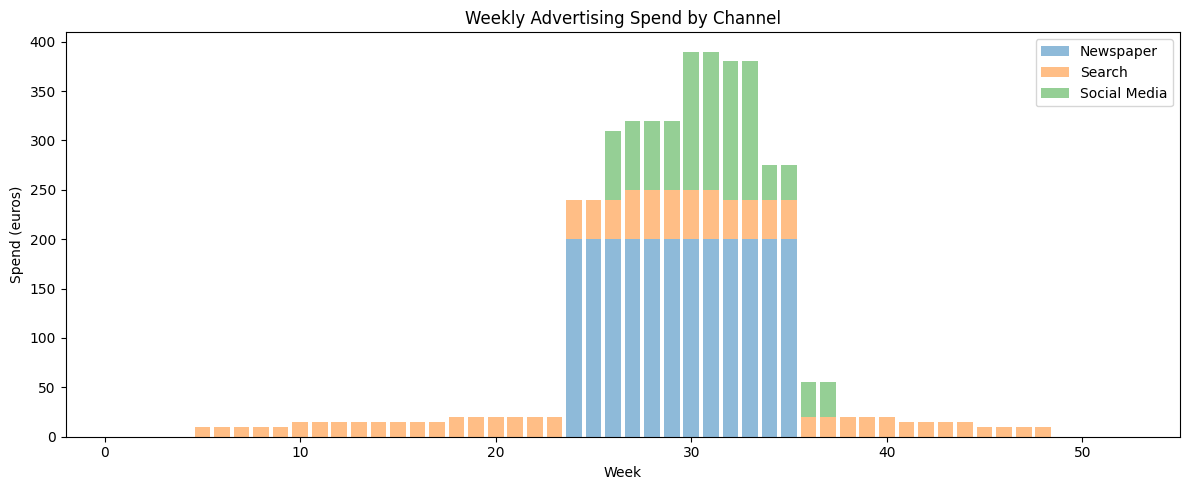

In [103]:
#weekly spend by channel stacked to see timing
plt.figure(figsize=(12, 5))
plt.bar(df['Week'], df['Newspaper'], label='Newspaper', alpha=0.5)
plt.bar(df['Week'], df['Search'], bottom=df['Newspaper'], label='Search', alpha=0.5)
plt.bar(df['Week'], df['Social_media'], bottom=df['Newspaper'] + df['Search'], label='Social Media', alpha=0.5)
plt.xlabel('Week')
plt.ylabel('Spend (euros)')
plt.title('Weekly Advertising Spend by Channel')
plt.legend()
plt.tight_layout()
plt.show()

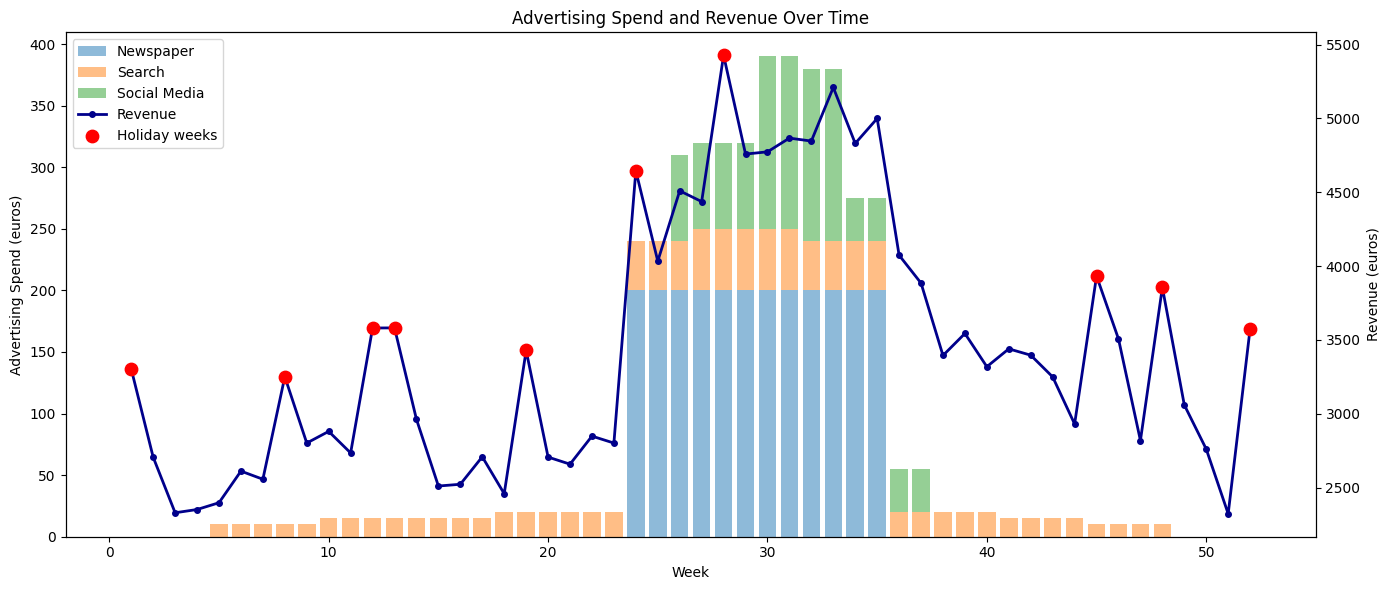

In [104]:
#overlay spend and revenue to see if they move together
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(df['Week'], df['Newspaper'], label='Newspaper', alpha=0.5)
ax1.bar(df['Week'], df['Search'], bottom=df['Newspaper'], label='Search', alpha=0.5)
ax1.bar(df['Week'], df['Social_media'], bottom=df['Newspaper'] + df['Search'], label='Social Media', alpha=0.5)
ax1.set_xlabel('Week')
ax1.set_ylabel('Advertising Spend (euros)')

ax2 = ax1.twinx()
ax2.plot(df['Week'], df['Revenue'], color='darkblue', linewidth=2, marker='o', markersize=4, label='Revenue')
ax2.set_ylabel('Revenue (euros)')

holidays = df[df['Holiday'] == 1]
plt.scatter(holidays['Week'], holidays['Revenue'], color='red', s=80, zorder=5, label='Holiday weeks')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Advertising Spend and Revenue Over Time')
plt.tight_layout()
plt.show()

All three channels are active only during weeks 24-35. Advertising, temperature, and revenue all peak at exactly the same time, which is going to make it hard to separate the advertising effect from seasonal demand in the regression.

### B.4 Scatter Plots

Scatter plots remove the time dimension and show the direct relationship between each predictor and revenue.

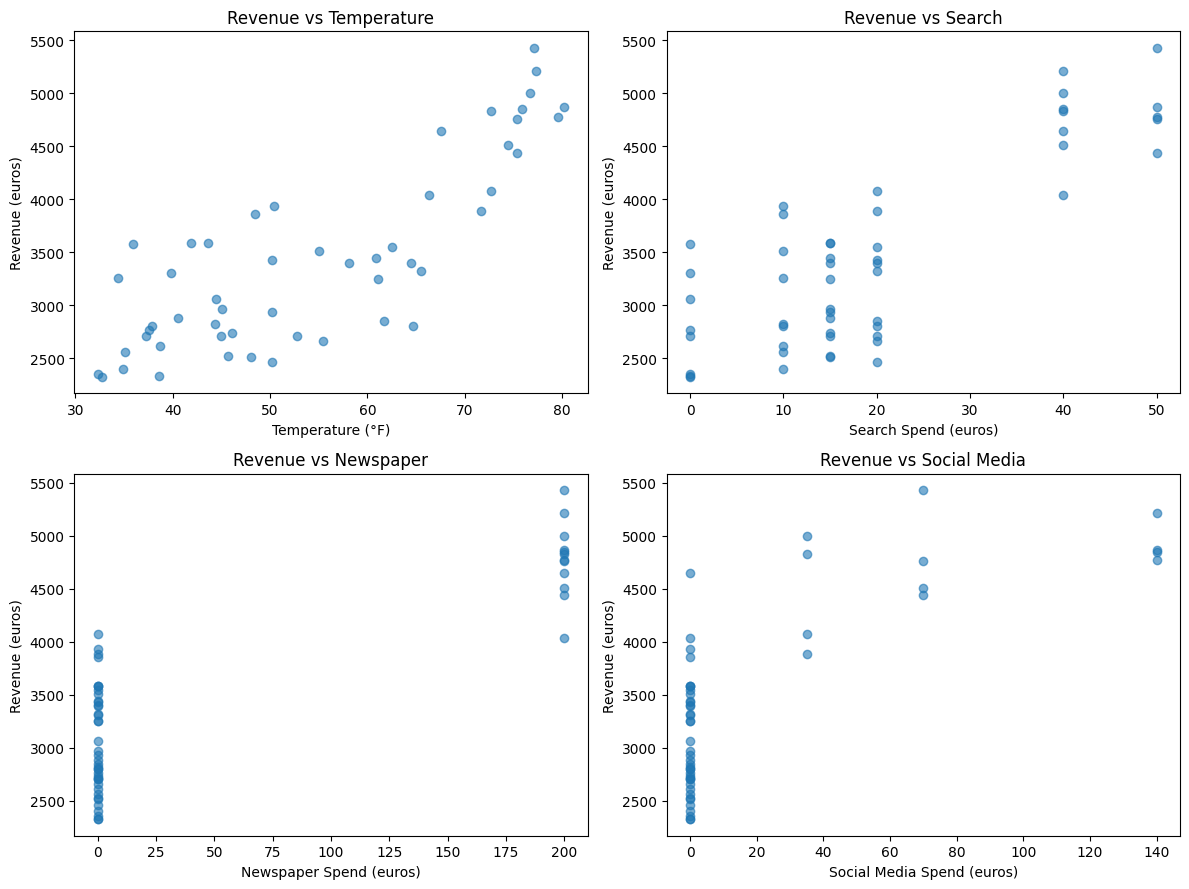

In [105]:
#scatter plots for all predictors to check individual relationships with revenue
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(df['Temperature'], df['Revenue'], alpha=0.6)
axes[0, 0].set_xlabel('Temperature (°F)')
axes[0, 0].set_ylabel('Revenue (euros)')
axes[0, 0].set_title('Revenue vs Temperature')

axes[0, 1].scatter(df['Search'], df['Revenue'], alpha=0.6)
axes[0, 1].set_xlabel('Search Spend (euros)')
axes[0, 1].set_ylabel('Revenue (euros)')
axes[0, 1].set_title('Revenue vs Search')

axes[1, 0].scatter(df['Newspaper'], df['Revenue'], alpha=0.6)
axes[1, 0].set_xlabel('Newspaper Spend (euros)')
axes[1, 0].set_ylabel('Revenue (euros)')
axes[1, 0].set_title('Revenue vs Newspaper')

axes[1, 1].scatter(df['Social_media'], df['Revenue'], alpha=0.6)
axes[1, 1].set_xlabel('Social Media Spend (euros)')
axes[1, 1].set_ylabel('Revenue (euros)')
axes[1, 1].set_title('Revenue vs Social Media')

plt.tight_layout()
plt.show()

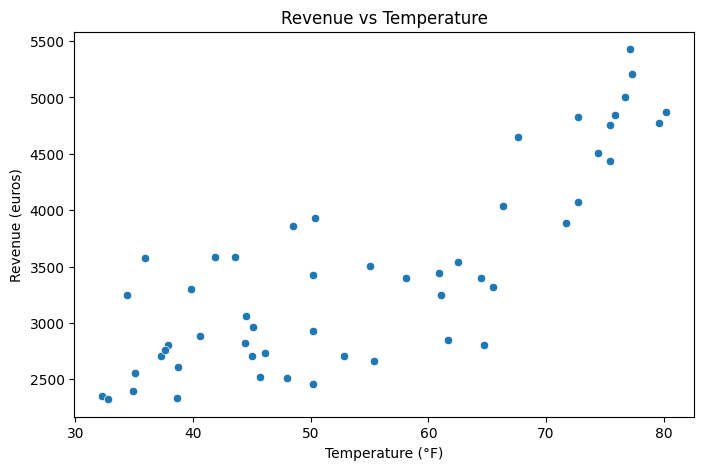

In [106]:
#zoom in on temperature since it shows the strongest relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temperature', y='Revenue', data=df)
plt.title('Revenue vs Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Revenue (euros)')
plt.show()

Temperature shows the clearest linear relationship with revenue. Newspaper shows a binary split between campaign and non-campaign weeks, but since all campaigns ran in summer the temperature effect is mixed in. Search and Social Media have the same problem: non-zero values only appear in warm weeks, so their individual contribution cannot be read from scatter plots alone.

### B.5 Correlation Analysis

Pearson correlation gives a numerical measure of how strongly variables move together. I focus on inter-predictor correlations too, not just with revenue, because high correlations between predictors are what cause multicollinearity.

In [107]:
#Pearson correlation matrix — I round to 3 decimals for readability
correlation_matrix = df.corr().round(3)
correlation_matrix

,Week,Revenue,Newspaper,Search,Social_media,Price_delta,Temperature,Holiday
Week,1.000,0.337,0.109,0.104,0.138,-0.365,0.363,-0.049
Revenue,0.337,1.000,0.847,0.818,0.744,0.171,0.819,0.234
Newspaper,0.109,0.847,1.000,0.897,0.775,0.436,0.748,-0.036
Search,0.104,0.818,0.897,1.000,0.747,0.547,0.881,-0.085
Social_media,0.138,0.744,0.775,0.747,1.000,0.333,0.699,-0.143
Price_delta,-0.365,0.171,0.436,0.547,0.333,1.000,0.323,0.006
Temperature,0.363,0.819,0.748,0.881,0.699,0.323,1.000,-0.183
Holiday,-0.049,0.234,-0.036,-0.085,-0.143,0.006,-0.183,1.000


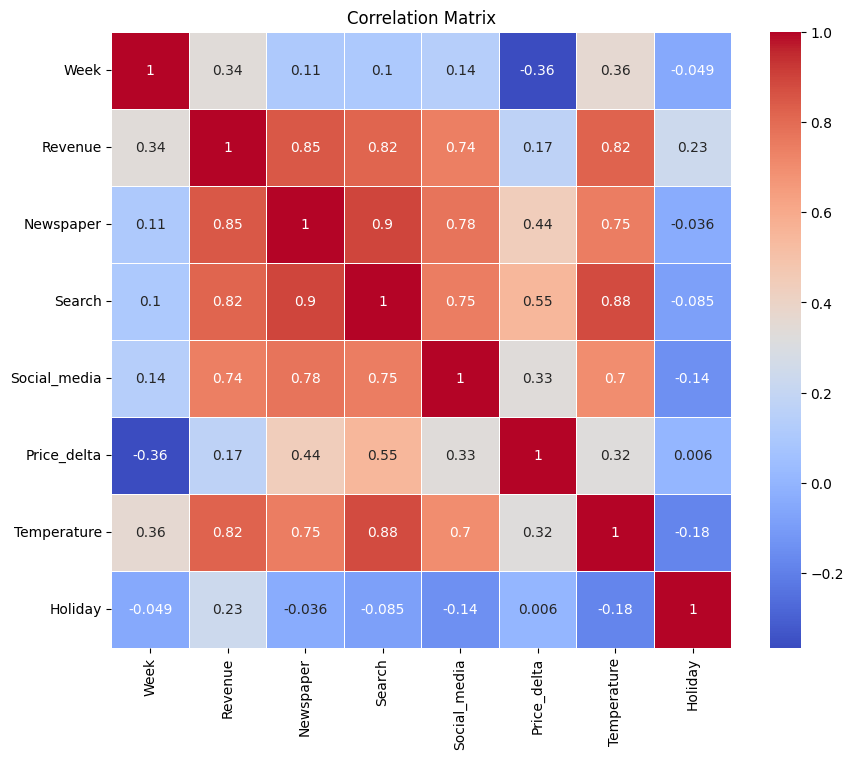

In [108]:
#heatmap to visualize correlations between all variables at once
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Revenue correlates most with Newspaper (0.85), Temperature (0.82), and Search (0.82). More importantly, Search and Newspaper are correlated at 0.90 and Search and Temperature at 0.88. Advertising and temperature moved together all year, which is exactly the problem that will show up in the regression.

## C. Multicollinearity Diagnostics (VIF)

VIF measures how much each predictor overlaps with the others. Below 5 is acceptable, 5-10 is moderate concern, above 10 is severe.

In [109]:
#compute VIF for each predictor
predictors = ['Newspaper', 'Search', 'Social_media', 'Price_delta', 'Temperature', 'Holiday']
X = sm.add_constant(df[predictors])
vif_data = pd.DataFrame({'Variable': predictors,
'VIF': [VIF(X.values, i+1) for i in range(len(predictors))]})
#sort descending to see the most problematic variables first
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data.round(2)

,Variable,VIF
0,Search,15.47
1,Newspaper,6.71
2,Temperature,6.24
3,Social_media,2.76
4,Price_delta,1.82
5,Holiday,1.08


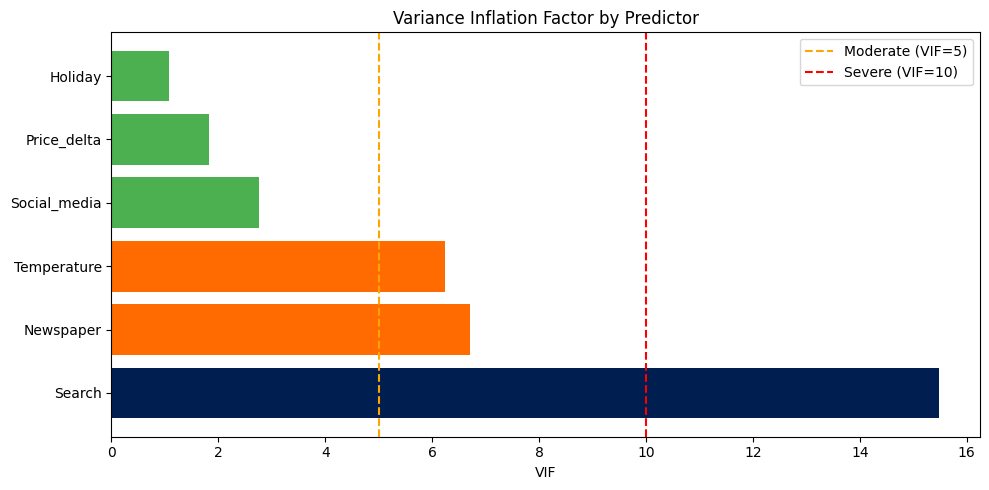

In [110]:
#color code by severity: red > 10, orange 5-10, green < 5
plt.figure(figsize=(10, 5))

colors = ['#001E50' if v > 10 else '#FF6B00' if v > 5 else '#4CAF50' for v in vif_data['VIF']]
plt.barh(vif_data['Variable'], vif_data['VIF'], color=colors)
plt.axvline(x=5, color='orange', linestyle='--', label='Moderate (VIF=5)')
plt.axvline(x=10, color='red', linestyle='--', label='Severe (VIF=10)')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor by Predictor')
plt.legend()
plt.tight_layout()
plt.show()

Search has a VIF of 15.47, the only variable in the severe zone. It overlaps too much with Temperature and Newspaper for the model to estimate its coefficient reliably. Newspaper (6.71) and Temperature (6.24) are in the moderate zone. The other three predictors are fine. I kept Search in the model because removing it would have hidden a real limitation of the data, and that is not useful for anyone who wants to use the model in practice.

## D. Ordinary Least Squares Modeling (OLS)

### D.1 Baseline vs Full Model

I start with a simple baseline using only Newspaper, the predictor with the highest correlation with revenue (r = 0.85), to have a reference point before adding all six predictors.

In [111]:
#baseline: Revenue ~ Newspaper only
X_baseline = sm.add_constant(df['Newspaper'])
baseline_model = sm.OLS(df['Revenue'], X_baseline).fit()
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     127.1
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           2.44e-15
Time:                        18:44:37   Log-Likelihood:                -392.41
No. Observations:                  52   AIC:                             788.8
Df Residuals:                      50   BIC:                             792.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3044.3000     73.897     41.197      0.0

The baseline explains 72% of revenue variance (R2 = 0.72). The Newspaper coefficient is 8.67, so a full campaign week (200 euros) is associated with roughly 1734 euros in extra revenue. This is inflated though, because Newspaper only ran in summer and the model is picking up part of the temperature effect.

In [112]:
#full model: Revenue ~ all predictors
predictors = ['Newspaper', 'Search', 'Social_media', 'Price_delta', 'Temperature', 'Holiday']
X = sm.add_constant(df[predictors])
model = sm.OLS(df['Revenue'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     267.6
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           1.73e-33
Time:                        18:44:37   Log-Likelihood:                -331.64
No. Observations:                  52   AIC:                             677.3
Df Residuals:                      45   BIC:                             690.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1517.4329    132.695     11.436   

The full model reaches R2 = 0.97. Five out of six predictors are significant. Search is the only exception (p = 0.62), as expected from the VIF results.

The Newspaper coefficient dropped from 8.67 to 4.50 once Temperature is in the model. The baseline was attributing part of summer demand to Newspaper when temperature was the actual driver. A 200 euros campaign is now estimated at around 900 euros in extra revenue.

### D.2 Coefficient Interpretation

Each coefficient represents the estimated revenue change for a one-unit increase in that predictor, holding all others constant.

Holiday has the largest effect at 804 euros per week. Since this shows up throughout the year and not just in summer, it is genuinely independent from the seasonal pattern.

Temperature adds 27.61 euros per degree Fahrenheit. Across the full seasonal range in the dataset (32F to 80F), that accounts for roughly 1325 euros in revenue variation.

Newspaper contributes 4.50 euros per euro spent. Social Media contributes 3.71 euros per euro spent and is significant (p = 0.0001) despite only being active in summer.

Price Delta has a coefficient of -752 euros per unit, so a price increase of 0.5 is associated with a drop of around 376 euros in revenue.

Search is not significant (p = 0.62). This does not mean Search has no effect, it means the dataset cannot measure it separately from temperature because the two always moved together.

I export the dataset with the model's predicted values and residuals to Excel, together with the coefficients. The file is **available in the excel_validation folder of this repository.**

## E. Train/Test Forecasting

An R2 of 0.97 on training data does not guarantee the model generalises. I split the data in order of time: weeks 1 to 41 for training and weeks 42 to 52 for testing. With a random split, the model could have been trained on week 50 and tested on week 10, which means it would have learned from data that comes after the weeks it is trying to predict. A time-based split avoids this problem.

In [113]:
#chronological split: 80% train, 20% test
#I use a chronological split because this is time series data
split = 41
train = df.iloc[:split]
test = df.iloc[split:]
predictors = ['Newspaper', 'Search', 'Social_media', 'Price_delta', 'Temperature', 'Holiday']
X_train = sm.add_constant(train[predictors])
X_test = sm.add_constant(test[predictors])
y_train = train['Revenue']
y_test = test['Revenue']
print(f'Train: {len(train)} weeks (1-41)')
print(f'Test: {len(test)} weeks (42-52)')

Train: 41 weeks (1-41)
Test: 11 weeks (42-52)


Weeks 42-52 cover mid-autumn to year-end: temperatures drop from 61F to 33F, Newspaper and Social Media are inactive, Search is minimal. The test period is quite different from the training data, which makes this a meaningful check.

In [114]:
#fit on training data only
train_model = sm.OLS(y_train, X_train).fit()
print(train_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     256.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           8.05e-27
Time:                        18:44:37   Log-Likelihood:                -259.86
No. Observations:                  41   AIC:                             533.7
Df Residuals:                      34   BIC:                             545.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1613.7106    139.744     11.548   

Coefficients on the training set are very close to the full model in Section D. Search is again non-significant (p = 0.18). The model is stable.

In [115]:
#predict on test set
#add constant to align dimensions with the training model
X_test_fixed = sm.add_constant(test[predictors], has_constant='add')
y_pred = train_model.predict(X_test_fixed)

#evaluation metrics
rmse_test = np.sqrt(MSE(y_test, y_pred))
r2_test = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
mae_test = np.mean(np.abs(y_test - y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f'R2 (test): {r2_test:.4f}')
print(f'RMSE: {rmse_test:.2f}')
print(f'MAE: {mae_test:.2f}')
print(f'MAPE: {mape:.2f}%')

R2 (test): 0.8649
RMSE: 173.09
MAE: 155.53
MAPE: 5.03%


Test MAPE is 5%, so predictions are off by 5% on average on unseen data. The best prediction is week 48, a holiday week: actual 3856 euros, predicted 3790 euros. The worst is week 46 with no holiday and no advertising, where something outside the model drove revenue up unexpectedly.

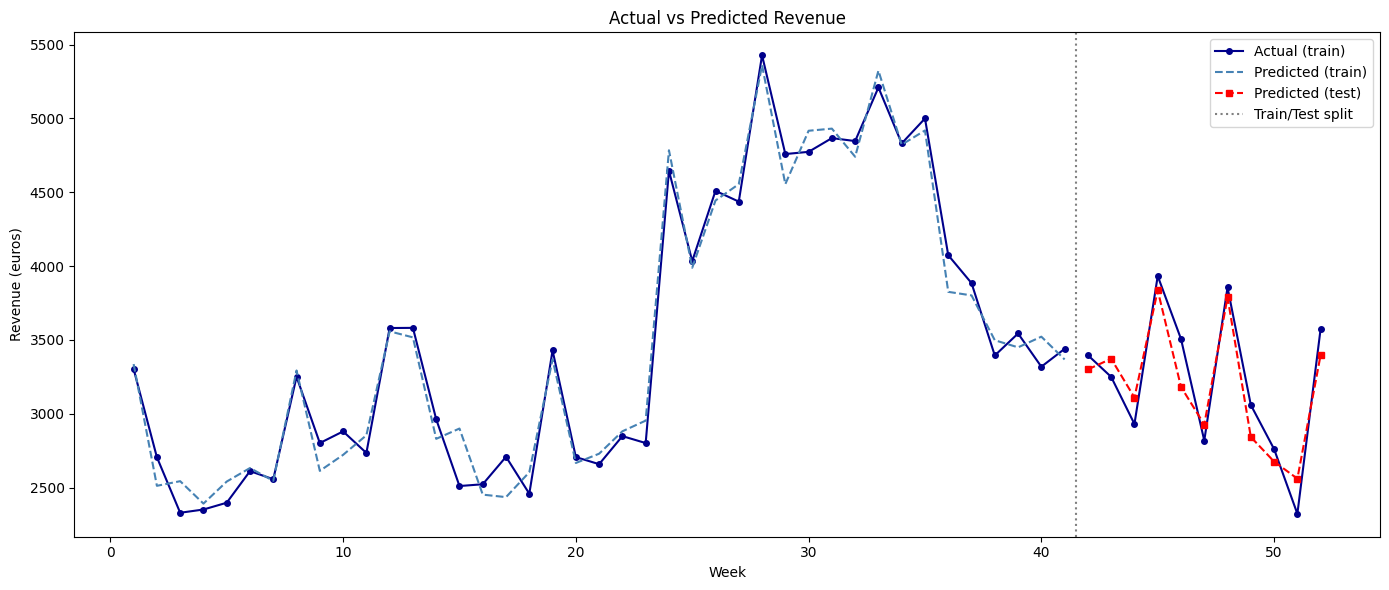

In [116]:
#plot actual vs predicted for the full timeline
plt.figure(figsize=(14, 6))

plt.plot(train['Week'], y_train, color='darkblue', marker='o', markersize=4,
linewidth=1.5, label='Actual (train)')
plt.plot(train['Week'], train_model.predict(X_train), color='steelblue',
linestyle='--', linewidth=1.5, label='Predicted (train)')

plt.plot(test['Week'], y_test, color='darkblue', marker='o', markersize=4, linewidth=1.5)
plt.plot(test['Week'], y_pred, color='red', linestyle='--', marker='s',
markersize=5, linewidth=1.5, label='Predicted (test)')

#vertical line to mark where training ends and test begins
plt.axvline(x=41.5, color='gray', linestyle=':', label='Train/Test split')

plt.xlabel('Week')
plt.ylabel('Revenue (euros)')
plt.title('Actual vs Predicted Revenue')
plt.legend()
plt.tight_layout()
plt.show()

The test predictions follow the autumn downward trend correctly with no systematic pattern of over or under-prediction.

## F. Residual Analysis

OLS relies on a few key assumptions. If they are violated, the coefficients and p-values from Section D are not reliable. I check the two most important ones visually.

Linearity: residuals should be randomly scattered around zero with no pattern. A curve or funnel shape would suggest the linear model is missing something.

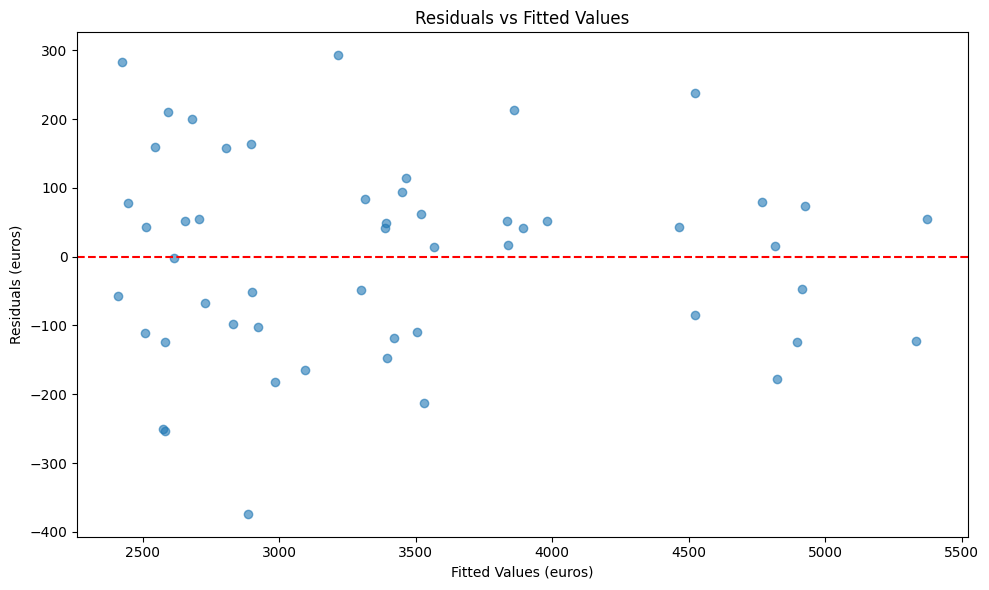

In [117]:
#extract fitted values and residuals from the full model
fitted = model.fittedvalues
residuals = model.resid

#residuals vs fitted: if linearity holds, points should be randomly scattered around zero
plt.figure(figsize=(10, 6))
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values (euros)')
plt.ylabel('Residuals (euros)')
plt.title('Residuals vs Fitted Values')
plt.tight_layout()
plt.show()

Residuals are randomly scattered around zero with constant spread. No pattern visible. Linearity holds.

Normality: p-values and confidence intervals from OLS assume residuals follow a normal distribution. I check with a Q-Q plot and a histogram.

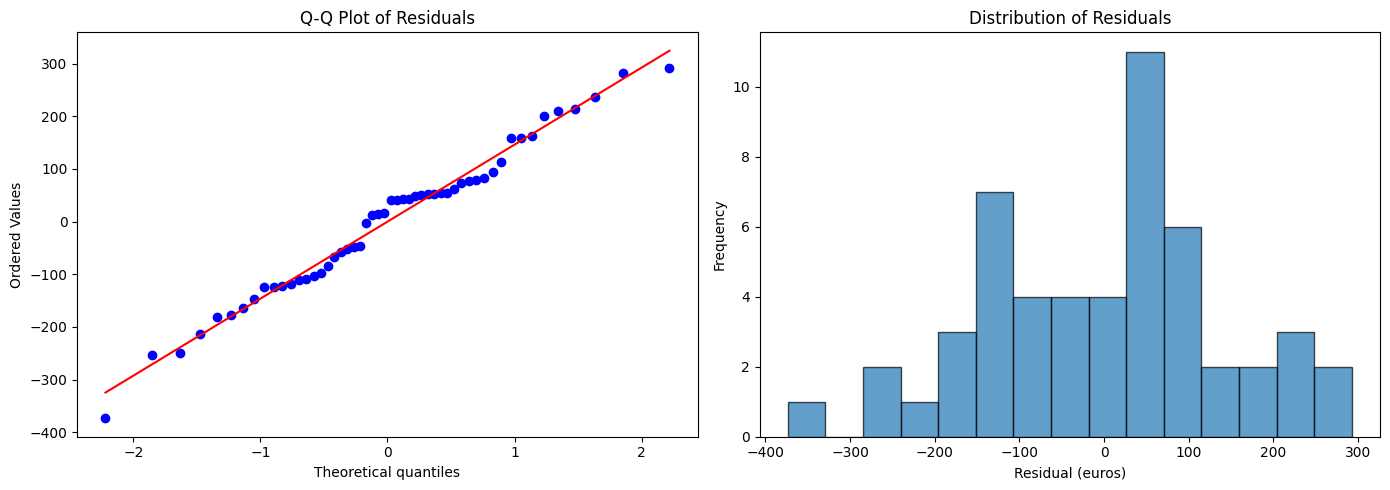

In [118]:
#Q-Q plot to check normality visually and histogram to see the distribution shape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')

axes[1].hist(residuals, bins=15, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residual (euros)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

Residuals fall closely along the Q-Q diagonal and the histogram is roughly symmetric. Normality holds. The results in Section D can be trusted.

## G. Conclusions and Recommendations

### G.1 Media Contribution Analysis

This chart breaks down the predicted revenue for each week into the contribution of each variable. Each bar shows how much each driver adds to or subtracts from the baseline (intercept) in that week.

The full Excel validation file including the decomposition chart is available in the excel_validation folder of this repository.

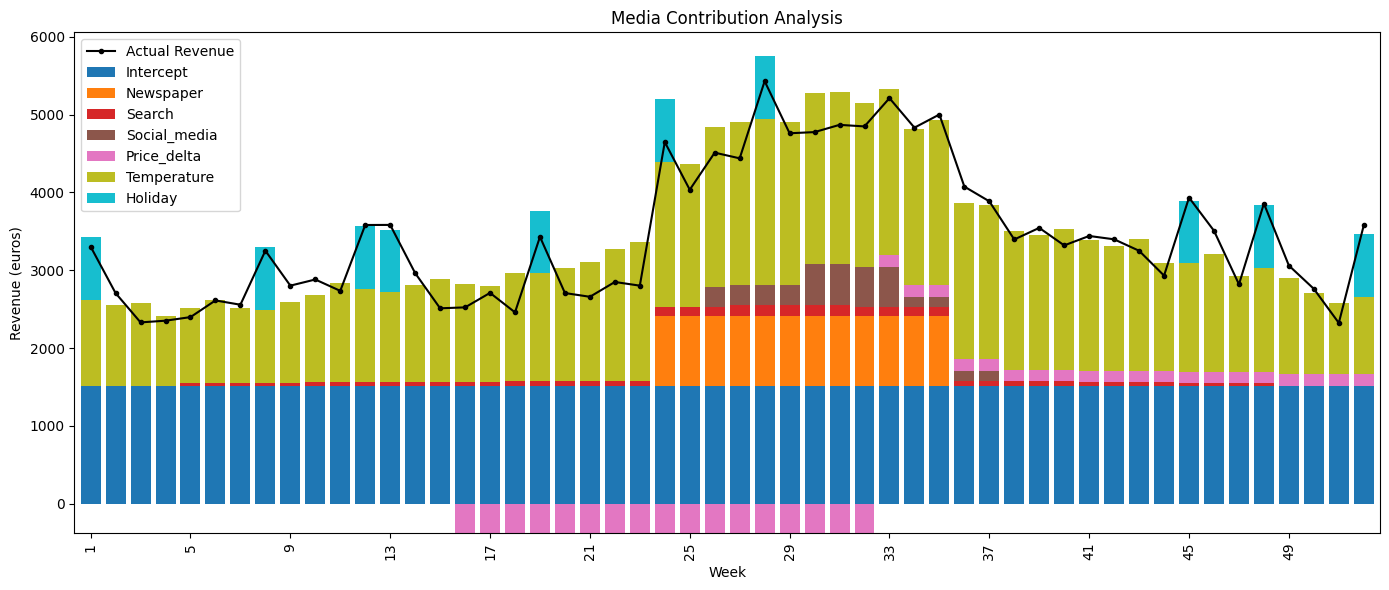

In [119]:
#decompose predicted revenue into variable contributions
coefficients = model.params

#calculate contribution of each variable
contributions = pd.DataFrame({
    'Intercept': coefficients['const'],
    'Newspaper': df['Newspaper'] * coefficients['Newspaper'],
    'Search': df['Search'] * coefficients['Search'],
    'Social_media': df['Social_media'] * coefficients['Social_media'],
    'Price_delta': df['Price_delta'] * coefficients['Price_delta'],
    'Temperature': df['Temperature'] * coefficients['Temperature'],
    'Holiday': df['Holiday'] * coefficients['Holiday']
})

#stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
contributions.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.8)
ax.plot(df['Week'] - 1, df['Revenue'], color='black', linewidth=1.5, marker='o', markersize=3, label='Actual Revenue')
ax.set_xlabel('Week')
ax.set_ylabel('Revenue (euros)')
ax.set_title('Media Contribution Analysis')
ax.set_xticks(range(0, 52, 4))
ax.set_xticklabels(range(1, 53, 4))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### G.2 Summary and Recommendations

The full model explains 97% of revenue variance and achieves a test MAPE of 5% on unseen data. The five significant drivers are Holiday (804 euros per week), Temperature (27.61 euros per degree F), Newspaper (4.50 euros per euro spent), Social Media (3.71 euros per euro spent), and Price Delta (-752 euros per tier). Search was not significant due to severe multicollinearity with Temperature. This does not mean that Search advertising does not work. It means that the data cannot tell us, because Search and Temperature moved together the entire year.

Holiday weeks are the most reliable lever available. The effect holds in every season, not just in summer. Campaigns should be planned around every public holiday in the calendar and holiday weeks should have their own dedicated budget rather than being absorbed into the general seasonal plan.

Advertising budget should be concentrated between weeks 20 and 36, where temperature and holiday effects overlap. Spending the same budget evenly across 52 weeks means investing in winter weeks where demand has a natural ceiling that no advertising can overcome.

Newspaper and Social Media are the two channels with a measurable return, at 4.50 and 3.71 euros per euro spent respectively. These estimates may be slightly overstated because both channels only ran in summer, so part of the advertising effect could still be seasonal demand. The real return is likely a bit lower, but both channels remain the most efficient ones in this dataset.

Before making any budget decision on Search, it should be tested in a quiet period, like a non-holiday week in autumn or winter, where its impact can be measured in isolation from temperature and the other channels.

With a 5% MAPE, the model is reliable enough to use for budget planning. The team can input planned spend, expected temperature and known holidays to project weekly revenue before committing to the next season.